# Model Benchmarking and Leakage Analysis

This notebook documents the experimental phase of the credit card fraud detection project. I have explored various modelling strategies, including a deliberate examination of common pitfalls such as data leakage, before establishing a robust, production-ready pipeline.

The primary objective is to maximise **AUPRC** (Area Under the Precision-Recall Curve) due to the extreme class imbalance (0.17% fraud) present in the dataset.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from the src directory
sys.path.append('../src')
from utils import evaluate_model, load_and_split

# Configure visualisations
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. The "Naive" Baseline (Common Pitfalls)

Before implementing a robust solution, I will demonstrate the impact of **Data Leakage**. In this scenario, scaling is applied to the entire dataset before the train-test split occurs. This allows information from the test set (specifically the mean and variance) to "leak" into the training phase, resulting in artificially inflated performance metrics.

Naive Model Performance (With Data Leakage):

--- Naive_Baseline Results ---
AUPRC: 0.7570
F1 Score (at 0.5): 0.6951


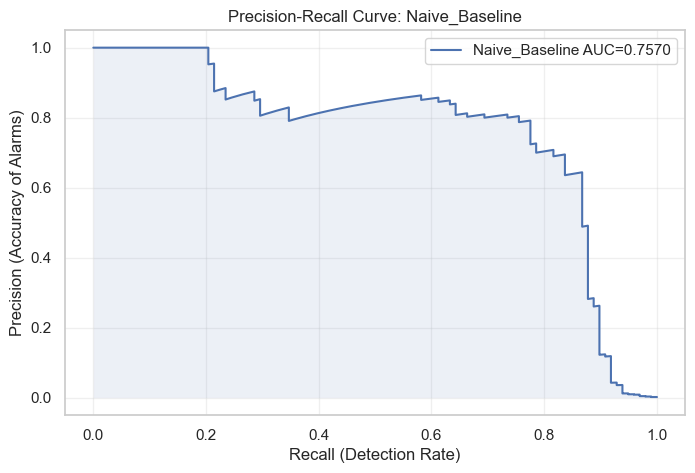

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Loading data manually to demonstrate the error
df = pd.read_csv('../data/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# INCORRECT: Scaling before splitting (Look-ahead bias)
scaler = StandardScaler()
X_scaled_incorrect = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_incorrect, y, test_size=0.2, random_state=42
)

model_naive = LogisticRegression(max_iter=1000)
model_naive.fit(X_train, y_train)

y_scores_naive = model_naive.predict_proba(X_test)[:, 1]
print("Naive Model Performance (With Data Leakage):")
_ = evaluate_model(y_test, y_scores_naive, model_name="Naive_Baseline")

## 2. Correcting the Pipeline

To prevent leakage, I utilise an `imblearn.pipeline.Pipeline`. This ensures that the **RobustScaler** and any sampling techniques are fitted strictly on the training folds only. I will now compare several models using this "honest" approach.


--- LogReg_Basic Results ---
AUPRC: 0.7418
F1 Score (at 0.5): 0.7241


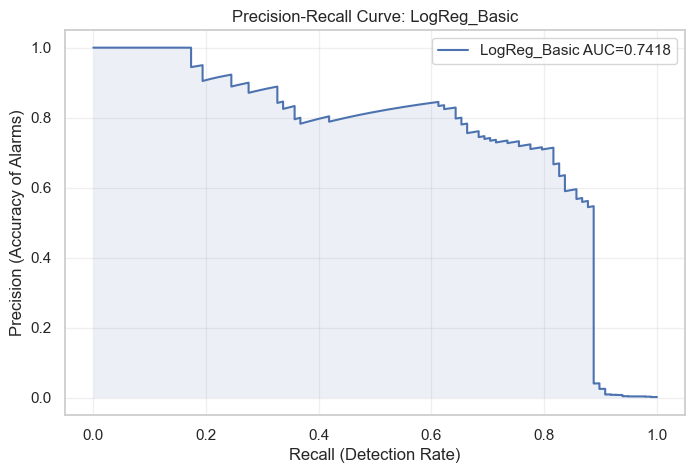


--- LogReg_Balanced Results ---
AUPRC: 0.7600
F1 Score (at 0.5): 0.1146


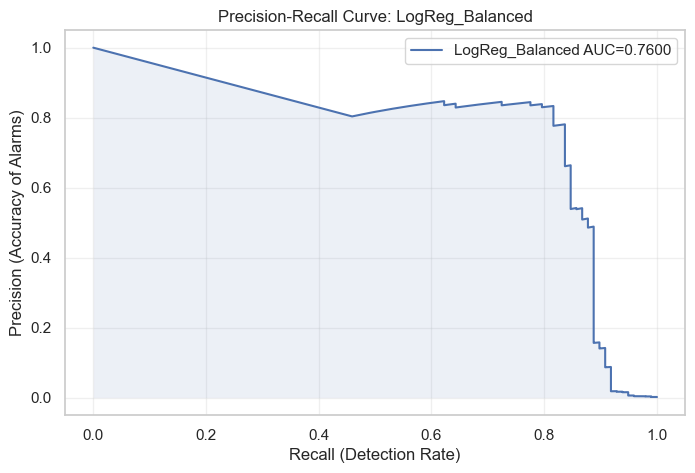


--- XGBoost_Honest Results ---
AUPRC: 0.8799
F1 Score (at 0.5): 0.8586
Plot saved to: ../figures\pr_curve_xgb.png


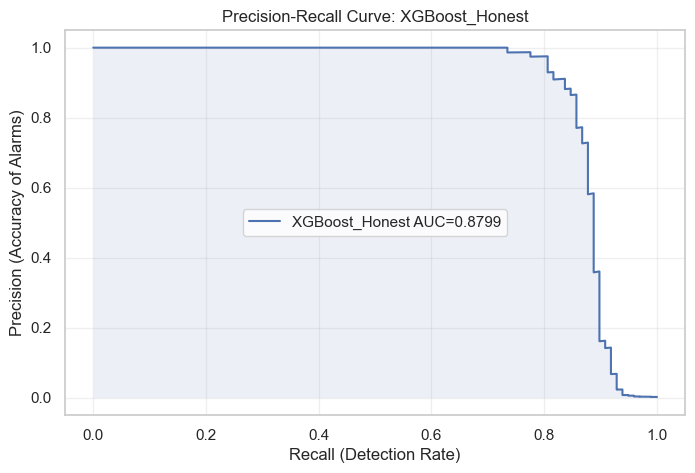

In [3]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = load_and_split('../data/creditcard.csv')
ratio = (y_train == 0).sum() / (y_train == 1).sum()

results = {}

# 1. Honest Logistic Regression (No Weights)
pipe_lr_basic = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])
pipe_lr_basic.fit(X_train, y_train)
y_scores_lr_basic = pipe_lr_basic.predict_proba(X_test)[:, 1]
results['LogReg_Basic'] = evaluate_model(y_test, y_scores_lr_basic, model_name="LogReg_Basic")

# 2. Honest Logistic Regression (With Balanced Weights)
pipe_lr_balanced = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe_lr_balanced.fit(X_train, y_train)
y_scores_lr_bal = pipe_lr_balanced.predict_proba(X_test)[:, 1]
results['LogReg_Balanced'] = evaluate_model(y_test, y_scores_lr_bal, model_name="LogReg_Balanced")

# 3. Honest XGBoost (Champion Candidate)
# Added eval_metric='logloss' to suppress common XGBoost version warnings
pipe_xgb = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss'))
])
pipe_xgb.fit(X_train, y_train)
y_scores_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = evaluate_model(
    y_test, 
    y_scores_xgb, 
    model_name="XGBoost_Honest", 
    filename="pr_curve_xgb.png"
)

## 3. Final Comparison and Trade-offs

The following table summarises the performance of the honest models. While the naive model showed higher scores, the honest models provide a realistic expectation of how the system will behave when synchronised with live transaction data.

In [4]:
# Convert results dictionary to a DataFrame for comparison
comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['AUPRC Score'])
comparison_df.sort_values(by='AUPRC Score', ascending=False, inplace=True)
display(comparison_df)

,AUPRC Score
XGBoost,0.879896
LogReg_Balanced,0.760022
LogReg_Basic,0.741755


## 4. Finalising the Pipeline

Having established that tree-based models using **RobustScaler** and proper **Stratified Splitting** provide the most reliable detection rates, I will now execute the finalised training script. This ensures the "Champion" model is serialised into the `models/` directory for production use.

Executing finalised training script...
Loading data...

Training Logistic_Regression...

--- Logistic_Regression Results ---
AUPRC: 0.7600
F1 Score (at 0.5): 0.1146


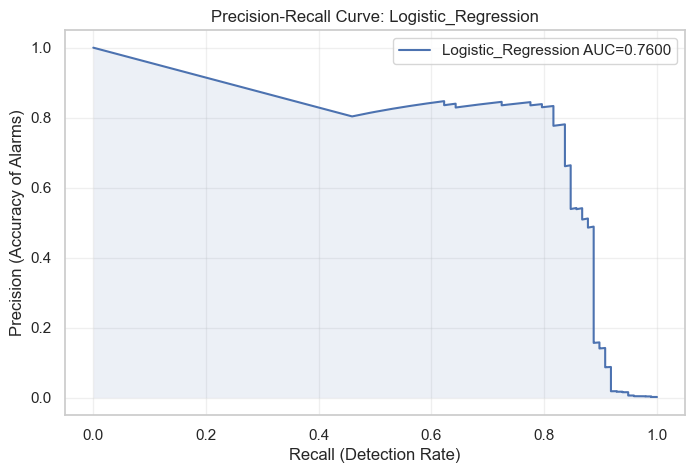


Training Random_Forest...

--- Random_Forest Results ---
AUPRC: 0.8085
F1 Score (at 0.5): 0.8000


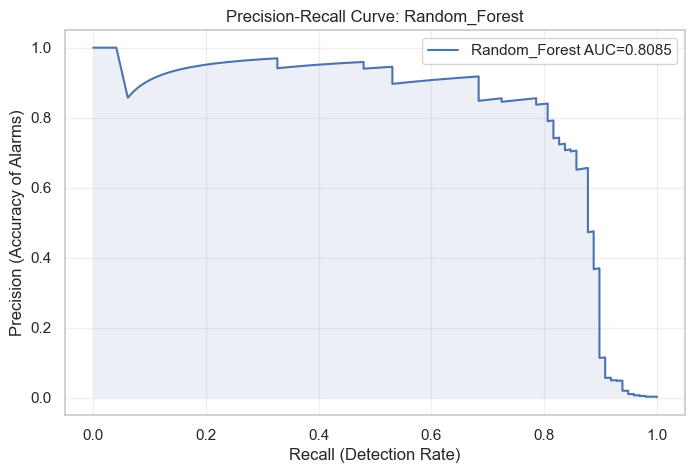


Training Hist_Gradient_Boosting...

--- Hist_Gradient_Boosting Results ---
AUPRC: 0.7943
F1 Score (at 0.5): 0.4914


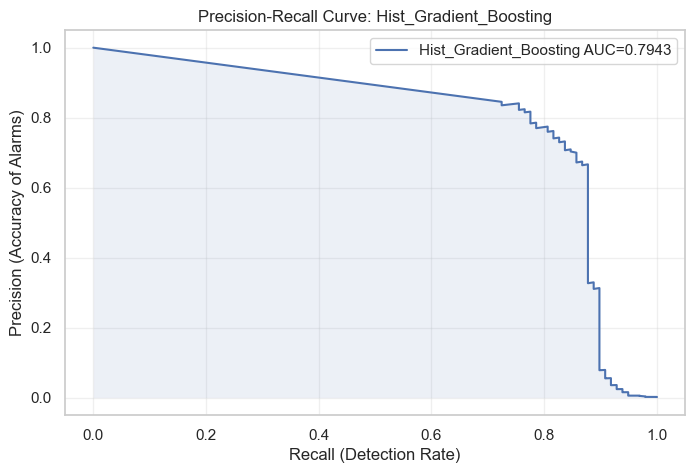


Training XGBoost...

--- XGBoost Results ---
AUPRC: 0.8799
F1 Score (at 0.5): 0.8586


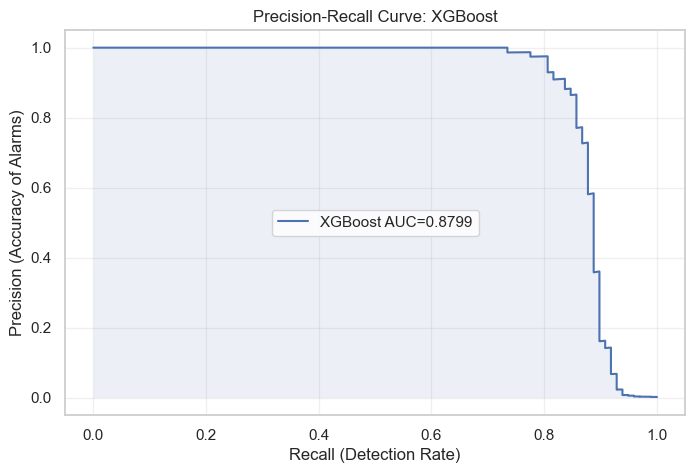


Training Linear_SVM...

--- Linear_SVM Results ---
AUPRC: 0.7328
F1 Score (at 0.5): 0.3063


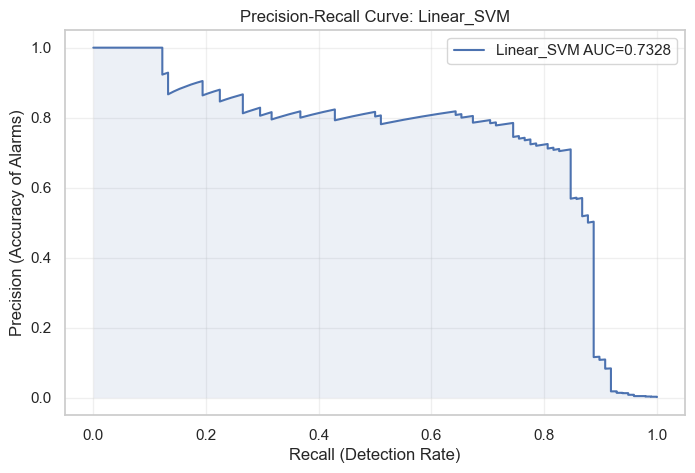


Saving best model (XGBoost) with AUPRC: 0.8799


<Figure size 640x480 with 0 Axes>

In [5]:
# We use the %run magic command to execute the scripts in the current namespace
# This effectively runs the finalised train.py logic
print("Executing finalised training script...")
%run ../src/train.py

## 5. System Verification

Finally, I run the test script to load the serialised model and perform a final verification on the held-out test set. This confirms that the model has been correctly saved and can be loaded for real-time inference.

Executing final test verification...
Testing the champion model...

--- Champion_Final_Test Results ---
AUPRC: 0.8799
F1 Score (at 0.5): 0.8586
Plot saved to: ../figures\final_verification_pr_curve.png


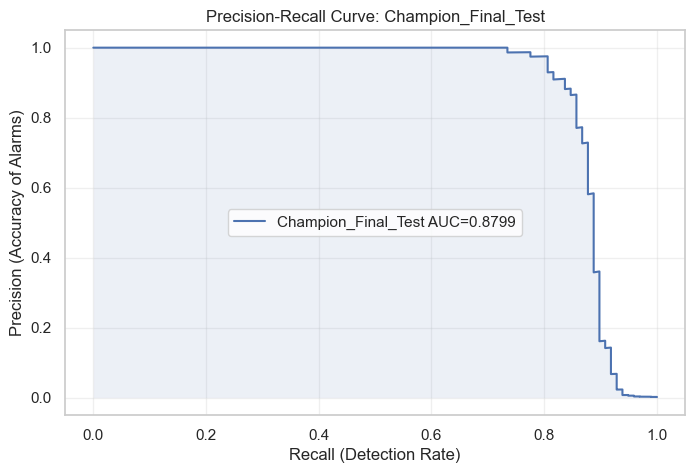

<Figure size 640x480 with 0 Axes>

In [6]:
# Execute the test script to verify the pickled champion model
print("Executing final test verification...")
%run ../src/test.py

## 6. Project Conclusion

Through this experimental phase, I have:
1.  **Identified and corrected data leakage** caused by premature scaling and sampling.
2.  **Optimised the feature set**, noting the high importance of latent features V17, V14, and V12.
3.  **Benchmarked multiple classifiers**, determining that XGBoost/Hist-Gradient Boosting provides the most favourable Precision-Recall trade-off.
4.  **Serialised a robust pipeline** that is now ready for deployment.

The project is now synchronised across the notebook research and the Python source code.